In [ ]:
#RPE neurons

In [350]:
import os
import pickle
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st

from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import RobustScaler, StandardScaler

import npc_lims
from dynamic_routing_analysis import data_utils, datacube_utils, spike_utils

# plt.rcParams['pdf.fonttype'] = 42 
# plt.rcParams.update({'font.size': 8,'pdf.fonttype':42})
matplotlib.rcParams['font.size'] = 12
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import matplotlib as mpl
mpl.rcParams['font.family'] = 'arial'

%load_ext autoreload
%autoreload 2
# %matplotlib widget

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [292]:
len(datacube_utils.get_passing_session_ids())
datacube_utils.datacube_config

DatacubeConfig(use_scratch_dir=True, datacube_version='v0.0.289')

In [154]:
# load a session
# session_id='703880_2024-04-18' #bad behavior
# session_id='715710_2024-07-17' #good behavior
# session_id='742903_2024-10-22' #the golden session
# session_id='668759_2023-07-12' #templeton

# session_id='743199_2024-12-05' #high number of VTA neurons
# session_id='743199_2024-12-04'
# session_id='733891_2024-09-18'
# session_id='737403_2024-09-26'

session_id='733891_2024-09-19' #SNc sessions
# session_id='714748_2024-06-26'
# session_id='737403_2024-09-26'
# session_id='733891_2024-09-18'
# session_id='733891_2024-09-16'

# session_info=npc_lims.get_session_info(session_id)
trials=data_utils.load_trials_or_units(session_id,'trials')
units=data_utils.load_trials_or_units(session_id,'units')

# print areas recorded
units['structure'].unique()


733891_2024-09-19 cached trials loaded
733891_2024-09-19 cached units loaded


array(['ACB', 'AId', 'APN', 'CA1', 'DG', 'FRP', 'IntG', 'LGd', 'MB',
       'MOs', 'MRN', 'OLF', 'ORBl', 'ORBvl', 'POL', 'PRE', 'ProS', 'RSPv',
       'SCig', 'SCop', 'SCsg', 'SCzo', 'SNc', 'SNr', 'SUB', 'TH', 'VISal',
       'VISl', 'VISli', 'VISp', 'VISpor', 'ZI', 'out of brain'],
      dtype=object)

In [156]:
# trials['response_time']
trials['is_response_or_rewarded'] = (trials['is_response'].values) | (trials['is_rewarded'].values)
# trials['response_or_rewarded_time']
trials.columns


Index(['start_time', 'stop_time', 'quiescent_start_time',
       'quiescent_stop_time', 'stim_start_time', 'stim_stop_time',
       'response_window_start_time', 'response_window_stop_time',
       'task_control_response_time', 'response_time', 'reward_time',
       'post_response_window_start_time', 'post_response_window_stop_time',
       'stim_name', 'block_index', 'rewarded_modality', 'trial_index',
       'trial_index_in_block', 'repeat_index', 'is_response', 'is_correct',
       'is_incorrect', 'is_hit', 'is_false_alarm', 'is_correct_reject',
       'is_miss', 'is_go', 'is_nogo', 'is_rewarded', 'is_noncontingent_reward',
       'is_contingent_reward', 'is_reward_scheduled', 'is_instruction',
       'is_aud_stim', 'is_vis_stim', 'is_catch', 'is_target', 'is_aud_target',
       'is_vis_target', 'is_nontarget', 'is_aud_nontarget', 'is_vis_nontarget',
       'is_vis_rewarded', 'is_aud_rewarded', 'is_block_switch', 'is_repeat',
       'is_opto', 'is_task_control_correct', 'session_idx

In [166]:
units_filtered['firing_rate']

id
1183     1.031409
1184    76.574143
1189    64.276510
1186     1.708033
1187    49.160679
1188    33.675266
1191     1.254419
1192    26.068064
1435     3.765960
1198     7.789419
1439     0.568401
1197     4.067212
1201    30.615013
Name: firing_rate, dtype: float64

In [173]:
# units=units.query('isi_violations_ratio<=0.5 and presence_ratio>=0.9 and amplitude_cutoff<=0.1')

# sel_structure = 'VTA'
sel_structure = 'SNc'

units_filtered = units.query(
    'presence_ratio>=0.7 and \
    isi_violations_ratio<=0.5 and \
    amplitude_cutoff<=0.1 and \
    activity_drift<=0.2 and \
    ~structure.isna() and ~location.isna() and \
    structure==@sel_structure and \
    firing_rate > 10'
    ).sort_values(['electrode_group_name', 'peak_channel', 'unit_id'])

time_before = 1.5
time_after = 1.51
binsize = 0.1
trial_da = spike_utils.make_neuron_time_trials_tensor(units_filtered, trials, time_before, time_after, binsize, event_name='reward_time')

In [174]:
# trial_da.sel(trials=486)
trial_da

<xarray.DataArray (unit_id: 6, time: 30, trials: 518)> Size: 746kB
array([[[100.,  80.,  60., ...,  nan, 110.,  90.],
        [110.,  90.,  70., ...,  nan, 110.,  80.],
        [100.,  80.,  80., ...,  nan, 100.,  90.],
        ...,
        [ 50.,  70., 110., ...,  nan,  70.,  80.],
        [ 50., 120., 100., ...,  nan,  70.,  70.],
        [ 60.,  80., 110., ...,  nan,  70.,  90.]],

       [[ 70.,  70.,  90., ...,  nan,  60.,  60.],
        [100.,  90.,  70., ...,  nan,  60.,  60.],
        [ 80.,  90.,  70., ...,  nan,  60.,  60.],
        ...,
        [100.,  90., 120., ...,  nan,  60.,  70.],
        [130., 100., 100., ...,  nan,  60.,  70.],
        [100.,  90., 120., ...,  nan,  60.,  60.]],

       [[ 30.,  60.,  90., ...,  nan,  30.,  50.],
        [ 30.,  70.,  70., ...,  nan,  10.,  50.],
        [ 30.,  50.,  70., ...,  nan,  30.,  60.],
        ...,
...
        ...,
        [  0.,   0.,  20., ...,  nan,  60.,  80.],
        [  0.,   0.,  40., ...,  nan,  60.,  50.],
        [  0.,   0.,   0., ...,  nan,  60.,  30.]],

       [[ 20.,  40.,  40., ...,  nan,   0.,  40.],
        [  0.,  20.,  50., ...,  nan,   0.,   0.],
        [ 10.,  10.,  70., ...,  nan,  10.,  40.],
        ...,
        [ 10.,  40.,  20., ...,  nan,  20.,  30.],
        [  0.,  20.,  10., ...,  nan,  20.,  30.],
        [  0.,  10.,  10., ...,  nan,  30.,  20.]],

       [[ 20.,  10.,  20., ...,  nan,  10.,  40.],
        [ 20.,  20.,  10., ...,  nan,  30.,  20.],
        [ 20.,  30.,  20., ...,  nan,  60.,  40.],
        ...,
        [  0.,  50.,  20., ...,  nan,  20.,  50.],
        [  0.,  20.,  10., ...,  nan,  50.,  50.],
        [ 20.,  20.,  10., ...,  nan,  50.,  40.]]])
Coordinates:
  * unit_id  (unit_id) object 48B '733891_2024-09-19_B-25' ... '733891_2024-0...
  * time     (time) float64 240B -1.45 -1.35 -1.25 -1.15 ... 1.15 1.25 1.35 1.45
  * trials   (trials) int64 4kB 0 1 2 3 4 5 6 7 ... 511 512 513 514 515 516 517

In [175]:
contingent_first_trial = trials.query('is_response and trial_index_in_block==0').index
contingent_first_trial

Index([0, 90, 181, 354], dtype='int64', name='id')

In [176]:
non_contingent_first_trial = trials.query('~is_response and trial_index_in_block==0').index
non_contingent_first_trial

Index([269, 440], dtype='int64', name='id')

In [177]:
#need to zscore before averaging across units


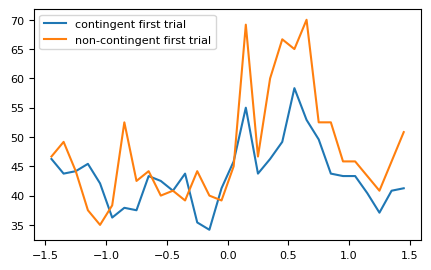

In [178]:
contingent_first_trial_da = trial_da.sel(trials=contingent_first_trial).mean(dim=['unit_id','trials'], skipna=True)
non_contingent_first_trial_da = trial_da.sel(trials=non_contingent_first_trial).mean(dim=['unit_id','trials'], skipna=True)

fig,ax=plt.subplots(1,1,figsize=(5,3))
ax.plot(contingent_first_trial_da.time,contingent_first_trial_da.values,label='contingent first trial',color='tab:blue')
ax.plot(non_contingent_first_trial_da.time,non_contingent_first_trial_da.values,label='non-contingent first trial',color='tab:orange')
ax.legend()

In [165]:
trial_da.sel(trials=non_contingent_first_trial)

<xarray.DataArray (unit_id: 13, time: 30, trials: 2)> Size: 6kB
array([[[ 10.,   0.],
        [  0.,   0.],
        [  0.,  10.],
        [  0.,   0.],
        [  0.,   0.],
        [  0.,   0.],
        [  0.,   0.],
        [ 10.,   0.],
        [  0.,   0.],
        [  0.,   0.],
        [  0.,   0.],
        [  0.,   0.],
        [  0.,   0.],
        [  0.,   0.],
        [  0.,   0.],
        [  0.,   0.],
        [  0.,   0.],
        [  0.,   0.],
        [  0.,   0.],
        [  0.,   0.],
...
        [ 40.,  30.],
        [ 20.,   0.],
        [ 40.,  40.],
        [ 40.,  30.],
        [ 50.,  30.],
        [ 40.,  30.],
        [ 40.,  10.],
        [ 50.,  40.],
        [ 40.,  40.],
        [ 20.,  50.],
        [ 10.,  40.],
        [ 40.,  40.],
        [ 10.,  20.],
        [ 20.,  20.],
        [ 40.,  20.],
        [ 10.,  20.],
        [ 20.,  10.],
        [ 10.,  10.],
        [ 30.,  20.],
        [ 40.,  10.]]])
Coordinates:
  * unit_id  (unit_id) object 104B '733891_2024-09-19_B-24' ... '733891_2024-...
  * time     (time) float64 240B -1.45 -1.35 -1.25 -1.15 ... 1.15 1.25 1.35 1.45
  * trials   (trials) int64 16B 269 440

In [138]:
is_hit_vis_target=trials.query('is_hit and is_vis_target and ~is_instruction').index
is_hit_vis_target

Index([  6,   9,  11,  12,  24,  30,  40,  41,  51,  52,  63,  66,  67,  71,
        74,  82,  84,  89, 193, 197, 199, 201, 208, 215, 221, 222, 223, 226,
       236, 242, 245, 250, 251, 261, 269, 373, 375],
      dtype='int64', name='id')

In [139]:
is_false_alarm_vis_target=trials.query('is_false_alarm and is_vis_target').index
is_false_alarm_vis_target

Index([95, 112, 125, 137, 287, 290, 297, 327, 362, 466, 468, 478], dtype='int64', name='id')

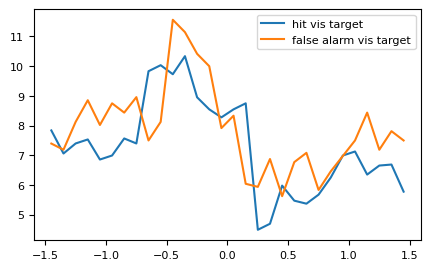

In [140]:
hit_vis_target_da = trial_da.sel(trials=is_hit_vis_target).mean(dim=['unit_id','trials'], skipna=True)
false_alarm_vis_target_da = trial_da.sel(trials=is_false_alarm_vis_target).mean(dim=['unit_id','trials'], skipna=True)

fig,ax=plt.subplots(1,1,figsize=(5,3))
ax.plot(hit_vis_target_da.time,hit_vis_target_da.values,label='hit vis target',color='tab:blue')
ax.plot(false_alarm_vis_target_da.time,false_alarm_vis_target_da.values,label='false alarm vis target',color='tab:orange')
ax.legend()

In [141]:
is_hit_aud_target=trials.query('is_hit and is_aud_target and ~is_instruction').index
is_hit_aud_target

Index([ 96, 101, 103, 109, 117, 121, 122, 128, 131, 140, 285, 286, 295, 296,
       300, 304, 306, 313, 315, 325, 326, 328, 335, 339, 347, 360, 361, 366,
       461, 462, 463, 464, 469, 471, 477, 486, 487, 492, 496, 504, 507, 516,
       517, 521],
      dtype='int64', name='id')

In [142]:
is_false_alarm_aud_target=trials.query('is_false_alarm and is_aud_target').index
is_false_alarm_aud_target

Index([87, 235, 239, 248, 252, 260, 377, 383, 399, 414, 430], dtype='int64', name='id')

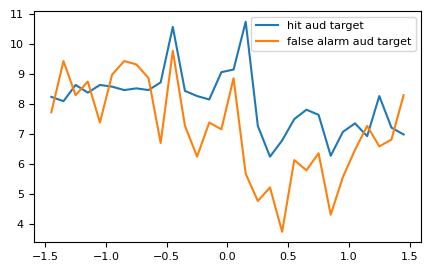

In [143]:
is_hit_aud_target_da = trial_da.sel(trials=is_hit_aud_target).mean(dim=['unit_id','trials'], skipna=True)
is_false_alarm_aud_target_da = trial_da.sel(trials=is_false_alarm_aud_target).mean(dim=['unit_id','trials'], skipna=True)

fig,ax=plt.subplots(1,1,figsize=(5,3))
ax.plot(is_hit_aud_target_da.time,is_hit_aud_target_da.values,label='hit aud target',color='tab:blue')
ax.plot(is_false_alarm_aud_target_da.time,is_false_alarm_aud_target_da.values,label='false alarm aud target',color='tab:orange')
ax.legend()

In [246]:
#sams way

In [247]:
#%%
def getGoodUnits(df):
    return df.query("isi_violations_ratio <= 0.5 & activity_drift <= 0.2 & presence_ratio >= 0.7 & amplitude_cutoff <= 0.1 & decoder_label != 'noise'")

def getAlignedSpikes(spikeTimes,startTimes,windowDur,binSize=0.001):
    bins = np.arange(0,windowDur+binSize,binSize)
    spikes = np.zeros((len(startTimes),bins.size-1))
    for i,start in enumerate(startTimes):
        startInd = np.searchsorted(spikeTimes,start)
        endInd = np.searchsorted(spikeTimes,start+windowDur)
        spikes[i] = np.histogram(spikeTimes[startInd:endInd]-start, bins)[0]
    return spikes

def getSpikeDur(s,thresh=0.2):
    neg = np.argmin(s)
    pos = np.argmax(s)
    if neg < pos:
        s = -s
        pos,neg = neg,pos
    start = np.where(s[:pos] < s[pos] * thresh)[0][-1]
    triphase = np.where(s[neg:] > s[pos] * thresh)[0] 
    if any(triphase):
        end = neg + triphase[-1] + 1
    else:
        end = neg + np.where(s[neg:] > s[neg] * thresh)[0][0]
    return start, end

In [257]:
all_performance.columns

Index(['start_time', 'stop_time', 'block_index', 'n_trials', 'n_responses',
       'n_hits', 'n_contingent_rewards', 'hit_rate', 'false_alarm_rate',
       'catch_response_rate', 'rewarded_modality', 'is_first_block_aud',
       'cross_modality_dprime', 'signed_cross_modality_dprime', 'vis_dprime',
       'aud_dprime', 'vis_target_response_rate', 'vis_nontarget_response_rate',
       'aud_target_response_rate', 'aud_nontarget_response_rate',
       'session_idx', 'date', 'subject_id', 'session_id', 'id'],
      dtype='object')

In [282]:
cache_version = 'v0.0.289'
all_performance=pl.scan_parquet('s3://aind-scratch-data/dynamic-routing/cache/nwb_components/'+cache_version+'/consolidated/performance.parquet').collect().to_pandas()
all_good_behavior_sessions = []
for sel_session in all_performance['session_id'].unique():
    session_performance = all_performance.query('session_id==@sel_session')[['cross_modality_dprime','rewarded_modality','n_contingent_rewards']]
    n_good_vis=np.sum(session_performance.query('rewarded_modality=="vis" and n_contingent_rewards>=10')['cross_modality_dprime']>=1.0)
    n_good_aud=np.sum(session_performance.query('rewarded_modality=="aud" and n_contingent_rewards>=10')['cross_modality_dprime']>=1.0)

    if n_good_vis>=2 and n_good_aud>=2:
        all_good_behavior_sessions.append(sel_session)


In [283]:
len(all_good_behavior_sessions)


113

In [284]:
session_table=pl.scan_parquet('s3://aind-scratch-data/dynamic-routing/cache/nwb_components/'+cache_version+'/consolidated/session.parquet').collect()

In [285]:
session_table

session_description,identifier,session_start_time,timestamps_reference_time,experimenter,keywords,experiment_description,session_id,lab,institution,source_script,source_script_file_name,stimulus_notes,session_idx,date,subject_id,__index_level_0__,notes
str,str,"datetime[μs, America/Los_Angeles]","datetime[μs, America/Los_Angeles]",list[str],list[str],str,str,str,str,str,str,str,i64,date,i64,i64,str
"""ecephys session (day 1) with b…","""fcf89292-0076-4bc9-811c-e1358e…",2022-07-26 14:08:55 PDT,2022-07-26 14:08:55 PDT,"[""Jackie Kuyat""]","[""task"", ""sync"", … ""day_1""]","""sensory discrimination task ex…","""620263_2022-07-26""","""NP3""","""Neural Circuits & Behavior | M…","""https://github.com/samgale/Dyn…","""https://github.com/AllenInstit…","""templeton stage 2 vis maxvol""",0,2022-07-26,620263,0,null
"""ecephys session (day 2) with b…","""bf6882c8-28ff-4b3a-ba14-d21738…",2022-07-27 13:56:52 PDT,2022-07-27 13:56:52 PDT,"[""Jackie Kuyat""]","[""task"", ""sync"", … ""day_2""]","""sensory discrimination task ex…","""620263_2022-07-27""","""NP3""","""Neural Circuits & Behavior | M…","""https://github.com/samgale/Dyn…","""https://github.com/AllenInstit…","""templeton stage 2 vis maxvol""",0,2022-07-27,620263,0,null
"""ecephys session (day 1) with b…","""f31b015c-d4c9-49c4-b3c0-054e8b…",2022-08-02 15:39:59 PDT,2022-08-02 15:39:59 PDT,"[""Jackie Kuyat""]","[""task"", ""sync"", … ""day_1""]","""sensory discrimination task ex…","""620264_2022-08-02""","""NP3""","""Neural Circuits & Behavior | M…","""https://github.com/samgale/Dyn…","""https://github.com/AllenInstit…","""templeton stage 2 aud record""",0,2022-08-02,620264,0,null
"""ecephys session (day 1) with b…","""f957c6e0-d59e-49d9-86a4-c2dbde…",2022-08-15 11:22:17 PDT,2022-08-15 11:22:17 PDT,"[""Jackie Kuyat""]","[""task"", ""sync"", … ""brainwide_survey""]","""visual-auditory task-switching…","""626791_2022-08-15""","""NP3""","""Neural Circuits & Behavior | M…","""https://github.com/samgale/Dyn…","""https://github.com/AllenInstit…","""stage 5 ori tone""",0,2022-08-15,626791,0,null
"""ecephys session (day 3) with b…","""7ca9a5f4-8043-4241-9cff-256161…",2022-08-17 13:24:54 PDT,2022-08-17 13:24:54 PDT,"[""Jackie Kuyat""]","[""task"", ""sync"", … ""brainwide_survey""]","""visual-auditory task-switching…","""626791_2022-08-17""","""NP3""","""Neural Circuits & Behavior | M…","""https://github.com/samgale/Dyn…","""https://github.com/AllenInstit…","""stage 5 ori tone""",0,2022-08-17,626791,0,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ecephys session (day 3) withou…","""34223192-17f0-487e-b5b3-7a8e36…",2026-04-03 12:16:54 PDT,2026-04-03 12:16:54 PDT,"[""Sam Gale""]","[""task"", ""ephys"", … ""brainwide_survey""]","""visual-auditory task-switching…","""850217_2026-04-03""","""NP2""","""Neural Circuits & Behavior | M…","""https://raw.githubusercontent.…","""https://github.com/AllenInstit…","""stage 5 AMN ori moving""",0,2026-04-03,850217,0,null
"""ecephys session (day 5) withou…","""87d1066a-b72e-45a2-8bc1-26c3c4…",2026-04-06 13:34:15 PDT,2026-04-06 13:34:15 PDT,"[""Sam Gale""]","[""task"", ""ephys"", … ""brainwide_survey""]","""visual-auditory task-switching…","""850217_2026-04-06""","""NP2""","""Neural Circuits & Behavior | M…","""https://raw.githubusercontent.…","""https://github.com/AllenInstit…","""stage 5 ori AMN moving""",0,2026-04-06,850217,0,null
"""ecephys session (day 1) withou…","""542fe529-d74c-4938-b048-505bca…",2026-04-22 10:18:59 PDT,2026-04-22 10:18:59 PDT,"[""Mikayla Carlson""]","[""task"", ""sync"", … ""brainwide_survey""]","""visual-auditory task-switching…","""854390_2026-04-22""","""NP3""","""Neural Circuits & Behavior | M…","""https://raw.githubusercontent.…","""https://github.com/AllenInstit…","""stage 5 ori AMN moving""",0,2026-04-22,854390,0,null


In [286]:
def standard_brainwide_filter() -> pl.Expr:
    # Cache v0.0.289 uses "prod" and "brainwide_survey" keyword labels.
    required = ("prod", "brainwide_survey", "task", "ephys", "ccf")
    excluded = (
        "issues",
        "opto_perturbation",
        "opto_control",
        "injection_perturbation",
        "injection_control",
        "muscimol_perturbation",
        "hab",
        "training",
        "context_naive",
        "templeton",
    )
    return pl.all_horizontal(
        *[pl.col("keywords").list.contains(keyword) for keyword in required],
        *[~pl.col("keywords").list.contains(keyword) for keyword in excluded],
    )

In [287]:
filtered_sessions = session_table.filter(standard_brainwide_filter())


In [288]:
len(filtered_sessions)

127

In [238]:
cache_version = 'v0.0.289'

unitsPath='s3://aind-scratch-data/dynamic-routing/cache/nwb_components/'+cache_version+'/consolidated/units.parquet'
allUnitsDf = pl.scan_parquet(unitsPath)

#%%
areas = ('SNc','VTA')

unitsDf = allUnitsDf.filter(
    pl.col('structure').is_in(areas),
    pl.col('session_id').is_in(all_good_behavior_sessions)).collect().to_pandas()

sessionIds = unitsDf['session_id'].unique()


# nUnits = [getGoodUnits(allUnitsDf.filter(pl.col('session_id')==sid).filter(pl.col('structure').is_in(areas)).collect().to_pandas()).shape[0] for sid in sessionIds]

# nSessions = np.sum(np.array(nUnits)>0)

#%%
unitsDf = pd.read_parquet(r"\\allen\programs\mindscope\workgroups\dynamicrouting\ben\SNc_VTA_waveforms.parquet")
unitsDf = getGoodUnits(unitsDf)

#%%
nUnits = unitsDf.shape[0]
nSessions = len(unitsDf['session_id'].unique())
nMice = len(np.unique([session[:6] for session in unitsDf['session_id']]))

#%%
trialsDf = pd.read_parquet('s3://aind-scratch-data/dynamic-routing/cache/nwb_components/'+cache_version+'/consolidated/trials.parquet')

In [321]:
response_or_reward_time=np.full((trialsDf.shape[0],),np.nan)
response_or_reward_time[trialsDf['is_response']]=trialsDf['response_time'][trialsDf['is_response']]
response_or_reward_time[trialsDf['is_rewarded']]=trialsDf['reward_time'][trialsDf['is_rewarded']]
trialsDf['response_or_reward_time']=response_or_reward_time

In [239]:
# all_performance[['cross_modality_dprime','hit_rate', 'false_alarm_rate','rewarded_modality']]
# all_performance.columns
good_behavior_session_list=[]
for sel_session in sessionIds:
    print(sel_session)
    session_performance = all_performance.query('session_id==@sel_session')[['cross_modality_dprime','rewarded_modality']]
    print(session_performance)
    n_good_vis=np.sum(session_performance.query('rewarded_modality=="vis"')['cross_modality_dprime']>=1.0)
    n_good_aud=np.sum(session_performance.query('rewarded_modality=="aud"')['cross_modality_dprime']>=1.0)
    print('n good vis blocks: ', n_good_vis, 'n good aud blocks: ', n_good_aud)
    if n_good_vis>=2 and n_good_aud>=2:
        print('pass!')
        good_behavior_session_list.append(sel_session)



708016_2024-04-29
     cross_modality_dprime rewarded_modality
460               3.238072               aud
461               1.413825               vis
462               1.768315               aud
463               2.679097               vis
464               3.090182               aud
465               2.592307               vis
n good vis blocks:  3 n good aud blocks:  3
pass!
714748_2024-06-26
     cross_modality_dprime rewarded_modality
556               2.236076               vis
557               1.200080               aud
558               3.688618               vis
559               0.644543               aud
560               2.573286               vis
561               1.325880               aud
n good vis blocks:  3 n good aud blocks:  2
pass!
733891_2024-09-18
     cross_modality_dprime rewarded_modality
730               3.553207               vis
731               2.734812               aud
732               2.142403               vis
733               1.252159          

In [241]:
unitsDf

,session_id,unit_id,structure,location,isi_violations_ratio,activity_drift,presence_ratio,amplitude_cutoff,decoder_label,peak_channel,waveform_mean,spike_times
0,737403_2024-09-24,737403_2024-09-24_B-7,SNc,SNc,0.000000,0.051805,1.000000,0.000022,sua,56,"[0.47735998034477234, -0.22464008629322052, -0...","[21.33536849368342, 21.392334959052995, 21.469..."
1,737403_2024-09-24,737403_2024-09-24_B-10,SNc,SNc,0.004319,0.198947,1.000000,0.000007,sua,58,"[0.6224400401115417, 0.5990400910377502, 1.001...","[20.36737191420275, 20.39967180006765, 20.4639..."
2,737403_2024-09-24,737403_2024-09-24_B-209,SNc,SNc,0.000000,0.108626,0.992188,0.000324,sua,56,"[0.7862399220466614, 0.5990395545959473, -0.00...","[47.57240911563066, 73.52648407080066, 76.4752..."
3,733891_2024-09-20,733891_2024-09-20_A-1,VTA,VTA,0.278509,0.083547,1.000000,0.000111,sua,1,"[-1.6286391019821167, -1.7456395626068115, -1....","[21.464816614774268, 21.54431637598968, 21.647..."
4,733891_2024-09-20,733891_2024-09-20_A-2,VTA,VTA,0.004948,0.140096,1.000000,0.000039,sua,2,"[-0.3744000196456909, 0.2340000420808792, -0.0...","[22.7344794678959, 24.195708412298444, 25.5628..."
...,...,...,...,...,...,...,...,...,...,...,...,...
173,733891_2024-09-18,733891_2024-09-18_A-290,VTA,VTA,0.000593,0.195408,1.000000,0.000041,sua,47,"[-1.6613993644714355, -0.692639946937561, -1.4...","[20.07154563298418, 20.12534547544767, 20.1654..."
174,733891_2024-09-18,733891_2024-09-18_A-293,VTA,VTA,0.034948,0.068159,1.000000,0.000059,sua,50,"[-1.1559592485427856, -0.2480403333902359, -0....","[20.037512399306838, 20.50701102452264, 20.851..."
175,733891_2024-09-18,733891_2024-09-18_A-294,VTA,VTA,0.000000,0.018827,1.000000,0.000371,sua,56,"[-1.6426805257797241, -1.9375197887420654, -2....","[20.836843392042013, 20.956976373602377, 22.67..."
176,733891_2024-09-18,733891_2024-09-18_A-295,VTA,VTA,0.009239,0.106439,1.000000,0.000040,sua,70,"[-0.7675195336341858, 0.2386801838874817, 0.37...","[22.536405082058206, 22.846237508141336, 23.26..."


In [242]:
# get spike times for selected units
unit_spike_times = {
    'unit_id':[],
    'spike_times':[],
}
for sel_session in unitsDf['session_id'].unique():
    sel_units = unitsDf.query('session_id==@sel_session')
    sel_trials = trialsDf.query('session_id==@sel_session')
    temp_units=data_utils.load_trials_or_units(sel_session,'units')
    for unit_id in sel_units['unit_id']:
        temp_spike_times=temp_units.query('unit_id==@unit_id')['spike_times'].values[0]
        unit_spike_times['unit_id'].append(unit_id)
        unit_spike_times['spike_times'].append(temp_spike_times)
    print(f"Loaded spike times for {len(sel_units)} units from session {sel_session}")


737403_2024-09-24 cached units not found, loading with npc_sessions
737403_2024-09-24 loading units failed


AttributeError: 'NoneType' object has no attribute 'query'

In [243]:
# temp_units.columns

In [310]:
# unitsDf = unitsDf.merge(pd.DataFrame(unit_spike_times), on='unit_id', how='left')
# unitsDf
subset_sessions=unitsDf['session_id'].unique()
subset_trials=trialsDf.query('session_id.isin(@subset_sessions)')

subset_trials.query('is_vis_target and is_vis_rewarded and ~is_instruction')['is_response'].mean()
subset_trials.query('is_aud_target and is_aud_rewarded and ~is_instruction')['is_response'].mean()

for sel_session in subset_sessions:
    sel_trials = subset_trials.query('session_id==@sel_session')
    if len(sel_trials)>0:
        print(sel_session)
        print('vis target hit rate: ', sel_trials.query('is_vis_target and is_vis_rewarded and ~is_instruction')['is_response'].mean())
        print('aud target hit rate: ', sel_trials.query('is_aud_target and is_aud_rewarded and ~is_instruction')['is_response'].mean())

737403_2024-09-24
vis target hit rate:  0.9473684210526315
aud target hit rate:  0.9285714285714286
733891_2024-09-20
vis target hit rate:  0.9074074074074074
aud target hit rate:  0.6666666666666666
714748_2024-06-26
vis target hit rate:  1.0
aud target hit rate:  0.603448275862069
708016_2024-04-29
vis target hit rate:  1.0
aud target hit rate:  0.9629629629629629
737403_2024-09-26
vis target hit rate:  0.7115384615384616
aud target hit rate:  0.7719298245614035
743199_2024-12-04
vis target hit rate:  1.0
aud target hit rate:  1.0
741137_2024-10-11
vis target hit rate:  0.6111111111111112
aud target hit rate:  0.9661016949152542
741137_2024-10-09
vis target hit rate:  0.6666666666666666
aud target hit rate:  0.8
741137_2024-10-08
vis target hit rate:  0.6607142857142857
aud target hit rate:  0.7333333333333333
741148_2024-10-18
vis target hit rate:  0.8771929824561403
aud target hit rate:  0.9298245614035088
737403_2024-09-27
vis target hit rate:  0.0
aud target hit rate:  0.85714285

In [309]:
trialsDf.query('session_id=="712815_2024-05-23"')

,start_time,stop_time,quiescent_start_time,quiescent_stop_time,stim_start_time,stim_stop_time,response_window_start_time,response_window_stop_time,task_control_response_time,response_time,...,opto_wavelength,opto_location_bregma_x,opto_location_bregma_y,opto_duration,opto_label,opto_power,opto_stim_name,is_single_opto_location,timeout_start_time,timeout_stop_time
id,,,,,,,,,,,,,,,,,,,,,


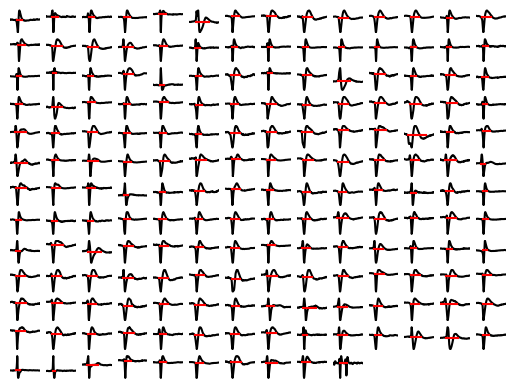

In [248]:
#%% waveforms
fig = plt.figure()
wf = np.stack(unitsDf['waveform_mean'])
n = wf.shape[0]
t = np.arange(wf.shape[1])/30000
nrows = int(n**0.5)
ncols = int(n**0.5 + 1)
gs = matplotlib.gridspec.GridSpec(nrows,ncols)
i = 0
j = 0
for w in wf:
    start,end = getSpikeDur(w)
    if j==ncols:
        i += 1
        j = 0
    ax = fig.add_subplot(gs[i,j])
    j += 1
    ax.plot(t,w,'k')
    ax.plot([start/30000,end/30000],[0,0],'r')
    ax.set_xlim([0.002,0.006])
    ax.set_axis_off()

In [249]:
#%%
spikeDur = []
for w in wf:
    start,end = getSpikeDur(w)
    spikeDur.append((end-start)/30000)
spikeDur = 1000 * np.array(spikeDur)

#%%
spontRate = []
for u,s in zip(unitsDf['unit_id'],unitsDf['session_id']):
    spikeTimes = unitsDf.query('unit_id==@u')['spike_times'].iloc[0]
    trials = trialsDf.query("session_id==@s")
    spontRate.append(np.mean(getAlignedSpikes(spikeTimes,trials['quiescent_start_time'],1.5,1.5),axis=0)[0])
spontRate = np.array(spontRate)

# spikeDur = unitsDf['peak_to_valley'].values*1000

c:\Users\ethan.mcbride\Code\dynamic_routing_analysis\.venv\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\ethan.mcbride\Code\dynamic_routing_analysis\.venv\Lib\site-packages\numpy\core\_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
c:\Users\ethan.mcbride\Code\dynamic_routing_analysis\.venv\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\ethan.mcbride\Code\dynamic_routing_analysis\.venv\Lib\site-packages\numpy\core\_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
c:\Users\ethan.mcbride\Code\dynamic_routing_analysis\.venv\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\ethan.mcbride\Code\dynamic_routing_ana

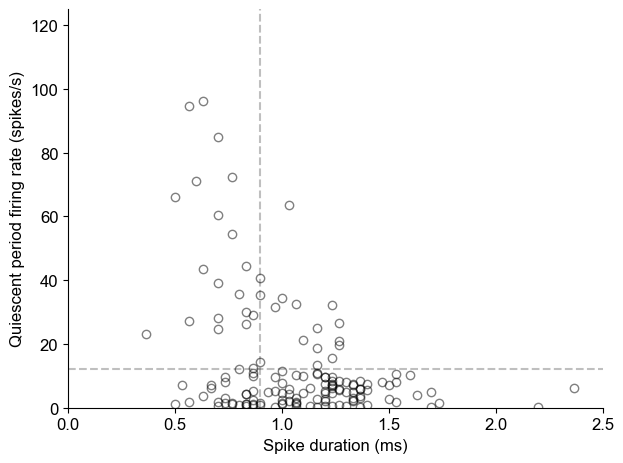

In [363]:
#%%
durThresh = 0.9
rateThresh = 12



fig = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.plot([durThresh]*2,[0,200],'k--',alpha=0.25)
ax.plot([0,4],[rateThresh]*2,'k--',alpha=0.25)
ax.plot(spikeDur,spontRate,'o',mec='k',mfc='none',alpha=0.5)
for side in ('right','top'):
    ax.spines[side].set_visible(False)
ax.tick_params(direction='out',top=False,right=False)
ax.set_xlim([0,2.5])
ax.set_ylim([0,125])
ax.set_xlabel('Spike duration (ms)')
ax.set_ylabel('Quiescent period firing rate (spikes/s)')
plt.tight_layout()


In [364]:
unitsDf['is_dopaminergic'] = (spikeDur > durThresh) & (spontRate < rateThresh)

nVTA_dop=np.sum(unitsDf.query('structure=="VTA"')['is_dopaminergic'])
nVTA_non_dop=np.sum(~unitsDf.query('structure=="VTA"')['is_dopaminergic'])
nSNc_dop=np.sum(unitsDf.query('structure=="SNc"')['is_dopaminergic'])
nSNc_non_dop=np.sum(~unitsDf.query('structure=="SNc"')['is_dopaminergic'])

print(f"VTA: {nVTA_dop} dopaminergic, {nVTA_non_dop} non-dopaminergic")
print(f"SNc: {nSNc_dop} dopaminergic, {nSNc_non_dop} non-dopaminergic")

VTA: 68 dopaminergic, 47 non-dopaminergic
SNc: 10 dopaminergic, 53 non-dopaminergic


c:\Users\ethan.mcbride\Code\dynamic_routing_analysis\.venv\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\ethan.mcbride\Code\dynamic_routing_analysis\.venv\Lib\site-packages\numpy\core\_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
c:\Users\ethan.mcbride\Code\dynamic_routing_analysis\.venv\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\ethan.mcbride\Code\dynamic_routing_analysis\.venv\Lib\site-packages\numpy\core\_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
c:\Users\ethan.mcbride\Code\dynamic_routing_analysis\.venv\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\ethan.mcbride\Code\dynamic_routing_ana

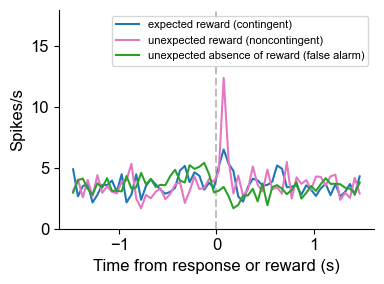

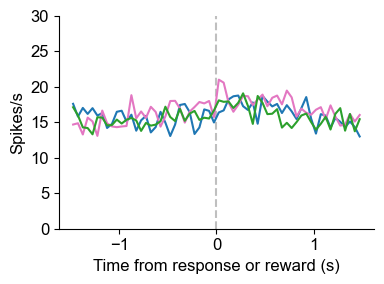

In [365]:
figsavepath = r"C:\Users\ethan.mcbride\OneDrive - Allen Institute\quick figures\2026-08-14_RPE_plots"
#%%
isDop = (spikeDur > durThresh) & (spontRate < rateThresh)

#%%
binSize = 0.05
preTime = 1.5
windowDur = preTime * 2
t = np.arange(0,windowDur,binSize) + binSize/2 - preTime
psth = {dop: {cont: [] for cont in ('contingent','noncontingent','false alarm')} for dop in ('dop','notDop')}
for dop,uind in zip(psth,(isDop,~isDop)):
    for u,s in zip(unitsDf[uind]['unit_id'],unitsDf[uind]['session_id']):
        spikeTimes = unitsDf[uind].query('unit_id==@u')['spike_times'].iloc[0]
        trials = trialsDf.query("session_id==@s")
        for cont in psth[dop]:
            if cont=='false alarm':
                ind = trials['is_target'] & trials['is_false_alarm'] & (trials['trial_index_in_block']<10)
            else:
                ind = (trials['trial_index_in_block']==0) & trials['is_'+cont+'_reward']
            startTimes = trials[ind]['response_or_reward_time']
            psth[dop][cont].append(np.mean(getAlignedSpikes(spikeTimes,startTimes-preTime,windowDur,binSize),axis=0))

#%%
labels={
    'contingent':'expected reward (contingent)',
    'noncontingent':'unexpected reward (noncontingent)',
    'false alarm':'unexpected absence of reward (false alarm)',
}
for dop,ylim in zip(psth,([0,18],[0,30])):
    fig = plt.figure(figsize=(4,3))
    ax = fig.add_subplot(1,1,1)
    ax.plot([0,0],[0,100],'k--',alpha=0.25)
    # for cont,alpha in zip(psth[dop],(1,0.6,0.3)):
    for cont,color in zip(psth[dop],('tab:blue','tab:pink','tab:green')):
        r = np.nanmean(psth[dop][cont],axis=0)/binSize
        # ax.plot(t,r,color='k',alpha=alpha,label=labels[cont])
        ax.plot(t,r,color=color,label=labels[cont])
        for side in ('right','top'):
            ax.spines[side].set_visible(False)
        ax.tick_params(direction='out',top=False,right=False)
        ax.set_ylim(ylim)
        ax.set_xlabel('Time from response or reward (s)')
        ax.set_ylabel('Spikes/s')
        if dop=='dop':
            ax.legend(fontsize=8,frameon=True)
    plt.tight_layout()

    plt.savefig(os.path.join(figsavepath,f"RPE_unit_plots_{dop}.pdf"),dpi=600)
    plt.savefig(os.path.join(figsavepath,f"RPE_unit_plots_{dop}.png"),dpi=600)

In [366]:
# (trials['is_target'] & trials['is_false_alarm']).sum()
# np.nanmean(psth['dop']['false alarm'],axis=0)
(trials['is_target'] & trials['is_correct_reject'] & (trials['trial_index_in_block']<20)).sum()

14

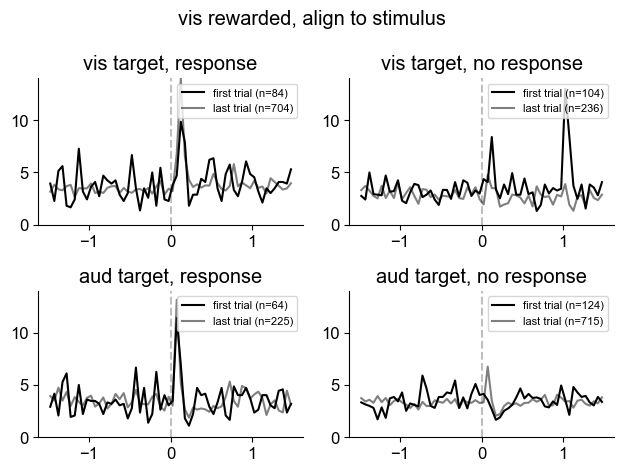

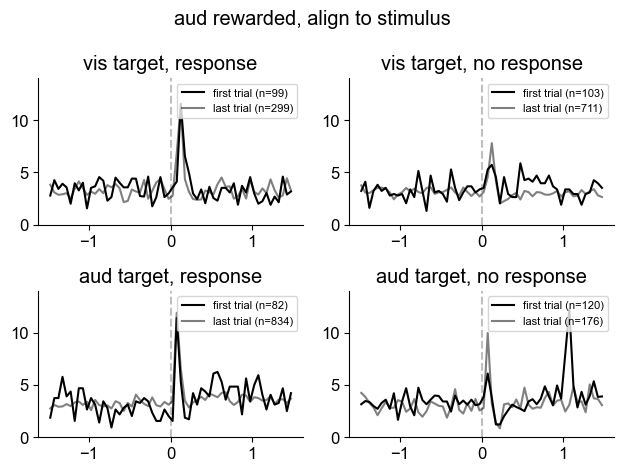

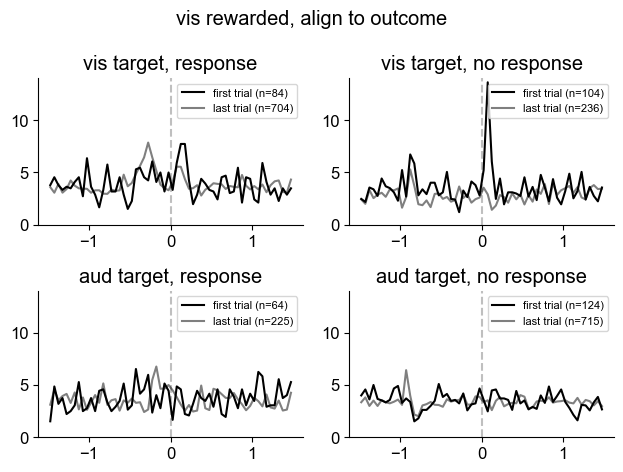

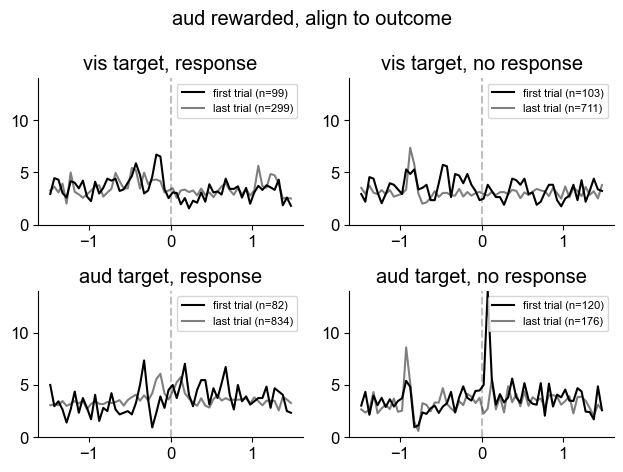

In [367]:
import matplotlib

#%%
uind = isDop
minTrials = 1
binSize = 0.05
preTime = 1.5
windowDur = preTime * 2
t = np.arange(0,windowDur+binSize,binSize)[:-1] + binSize/2 - preTime
blockType = ('vis rewarded','aud rewarded')
stimType = ('vis target','aud target')
trialType = ('first','last')
respType = ('response','no response')
alignTo = ('stimulus','outcome')
psth = {block: {stim: {trial: {resp: {align: [] for align in alignTo} for resp in respType} for trial in trialType} for stim in stimType} for block in blockType}
n_trials_contributed = {block: {stim: {trial: {resp: {align: [] for align in alignTo} for resp in respType} for trial in trialType} for stim in stimType} for block in blockType}
for u,s in zip(unitsDf[uind]['unit_id'],unitsDf[uind]['session_id']):
    spikeTimes = unitsDf[uind].query('unit_id==@u')['spike_times'].iloc[0]
    trials = trialsDf.query("session_id==@s")
    isResp = trials['is_response']
    isVisTarg = trials['is_vis_target']
    isAudTarg = trials['is_aud_target']
    isVisRew = trials['is_vis_rewarded']
    isAudRew = trials['is_aud_rewarded']
    for block in blockType:
        blockTrials = isVisRew if 'vis' in block else isAudRew
        for stim in stimType:
            stimTrials = isVisTarg if 'vis' in stim else isAudTarg
            for trial in trialType:
                isTrial = np.zeros(stimTrials.size,dtype=bool)
                nTrialsAvg = 1 if trial=='first' else 5
                i = slice(0,nTrialsAvg) if trial=='first' else slice(-nTrialsAvg,None)
                isTrial[[np.where(stimTrials & (trials['block_index']==b))[0][i] for b in range(1,6)]] = True
                for resp in respType:
                    ind = blockTrials & isTrial & (isResp if resp=='response' else ~isResp)
                    for align in alignTo:
                        if ind.sum() < minTrials:
                            psth[block][stim][trial][resp][align].append(np.full(t.size,np.nan))
                        else:
                            if align=='stimulus': 
                                startTimes = trials[ind]['stim_start_time']
                            elif align=='outcome':
                                startTimes =  trials[ind]['response_time'] if resp=='response' else trials[ind]['response_window_stop_time']
                            psth[block][stim][trial][resp][align].append(np.mean(getAlignedSpikes(spikeTimes,startTimes-preTime,windowDur,binSize),axis=0))
                            n_trials_contributed[block][stim][trial][resp][align].append(ind.sum())



# %%
for align in alignTo:
    for block in blockType:
        fig = plt.figure()
        fig.suptitle(block+', align to '+align)
        gs = matplotlib.gridspec.GridSpec(2,2)
        for i,stim in enumerate(stimType):
            for j,resp in enumerate(respType):
                ax = fig.add_subplot(gs[i,j])
                ax.plot([0,0],[0,100],'k--',alpha=0.25)
                for trial,alpha in zip(trialType,(1,0.5)):
                    r = np.nanmean(psth[block][stim][trial][resp][align],axis=0)/binSize
                    ax.plot(t,r,color='k',alpha=alpha,label=trial+' trial (n='+str(np.sum(n_trials_contributed[block][stim][trial][resp][align]))+')')
                for side in ('right','top'):
                    ax.spines[side].set_visible(False)
                ax.tick_params(direction='out',top=False,right=False)
                ax.set_ylim([0,14])
                # if i==0 and j==1:
                ax.legend(loc='upper right',fontsize=8)
                ax.set_title(stim+', '+resp)
        plt.tight_layout()


In [295]:
ind.sum()

3

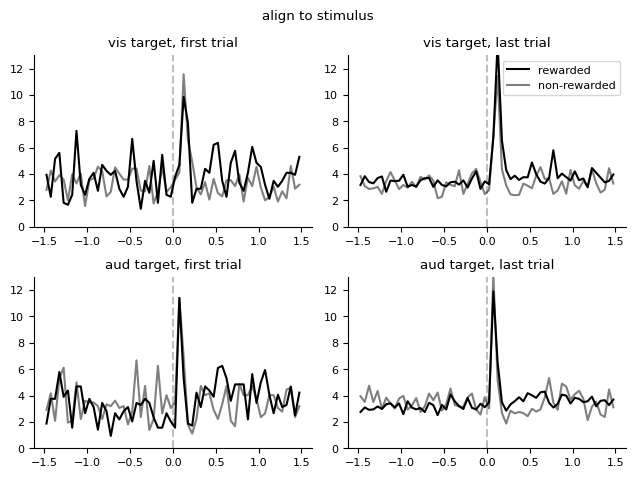

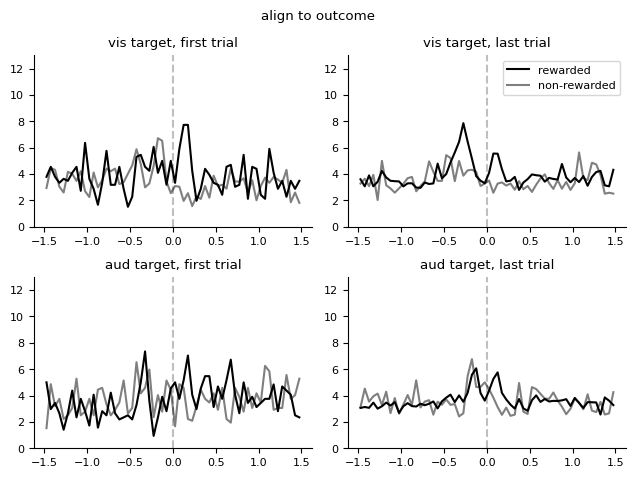

In [254]:
# %%
for align in alignTo:
    fig = plt.figure()
    fig.suptitle('align to '+align)
    gs = matplotlib.gridspec.GridSpec(2,2)
    for i,stim in enumerate(stimType):
        for j,trial in enumerate(trialType):
            ax = fig.add_subplot(gs[i,j])
            ax.plot([0,0],[0,100],'k--',alpha=0.25)
            for block in blockType:
                alpha,lbl = (1,'rewarded') if ('vis' in stim and 'vis' in block) or ('aud' in stim and 'aud' in block) else (0.5,'non-rewarded')
                r = np.nanmean(psth[block][stim][trial]['response'][align],axis=0)/binSize
                ax.plot(t,r,color='k',alpha=alpha,label=lbl)
            for side in ('right','top'):
                ax.spines[side].set_visible(False)
            ax.tick_params(direction='out',top=False,right=False)
            ax.set_ylim([0,13])
            if i==0 and j==1:
                ax.legend(loc='upper right',fontsize=8)
            ax.set_title(stim+', '+trial+' trial')
    plt.tight_layout()

# %%